In [1]:
!pip install numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install matplotlib
!pip install seaborn
!pip install textblob 
!pip install scikit-learn
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

In [4]:
df = pd.read_csv("twitter_training.csv")  # change filename if needed
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
df.columns = ['id', 'topic', 'sentiment', 'text']  # adjust if needed
df.dropna(inplace=True)
df['text'] = df['text'].str.lower()

In [6]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"
df['predicted_sentiment'] = df['text'].apply(get_sentiment)

**Sentiment Distribution Plot**

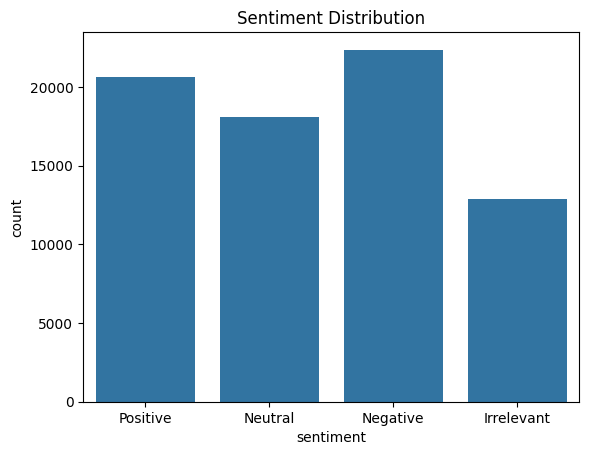

In [7]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

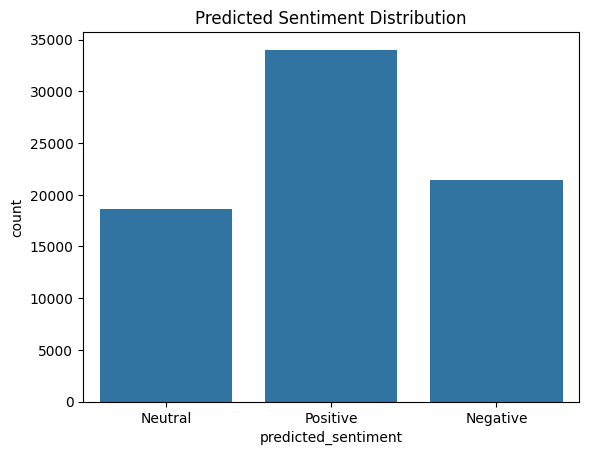

In [8]:
sns.countplot(x='predicted_sentiment', data=df)
plt.title("Predicted Sentiment Distribution")
plt.show()

**Sentiment by Topic**

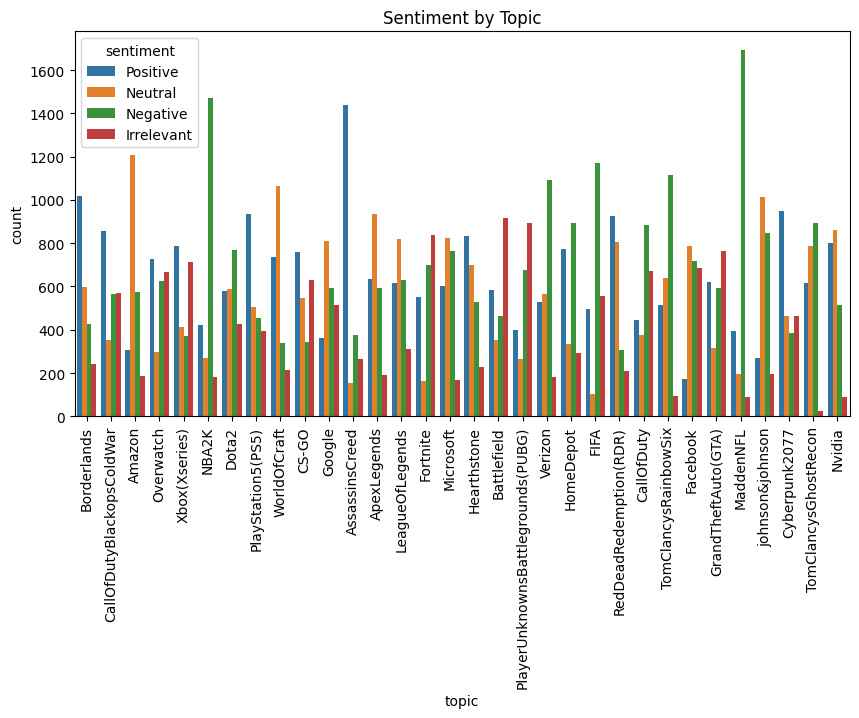

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='topic', hue='sentiment', data=df)
plt.xticks(rotation=90)
plt.title("Sentiment by Topic")
plt.show()

**Pie Chart**

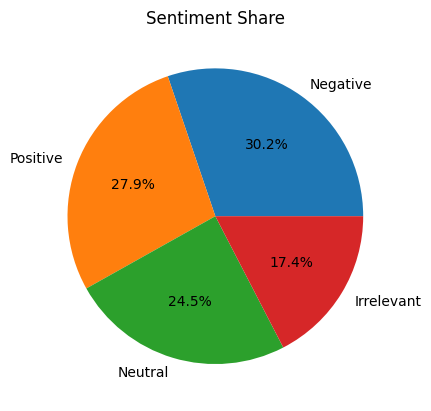

In [10]:
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Sentiment Share")
plt.ylabel("")
plt.show()

**Top Frequent Words**

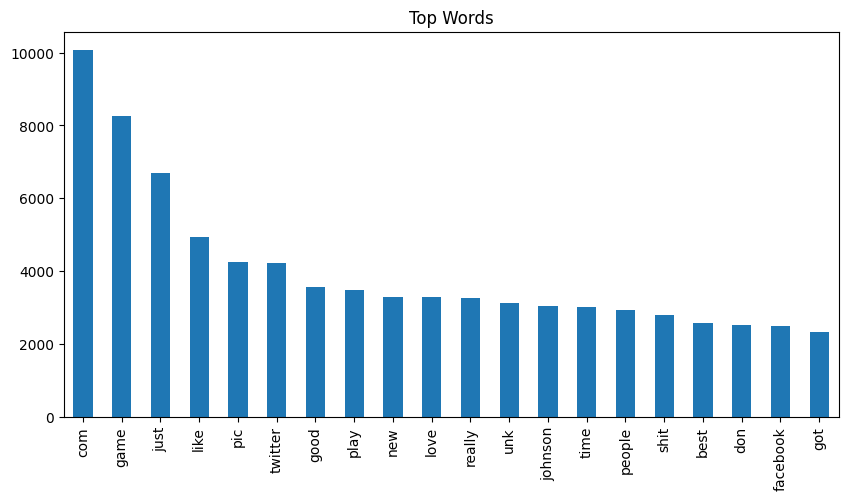

In [11]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['text'])

word_counts = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

word_counts.sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Top Words")
plt.show()